# Import Libraries
Imported pandas, numpy

Imported matplotlib & seaborn for visualization

Imported sklearn models & metrics

In [ ]:
# Basic Libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve

# Load Dataset

In [ ]:
# Upload your dataset first in Colab
from google.colab import files
uploaded = files.upload()

# Load CSV (replace filename with yours)
df = pd.read_csv("heart_processed.csv")

df.head()

Saving heart_processed.csv to heart_processed (1).csv


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0.0,0,True,True,False,False,True,False,False,False,True
1,49,160,180,0,156,1.0,1,False,False,True,False,True,False,False,True,False
2,37,130,283,0,98,0.0,0,True,True,False,False,False,True,False,False,True
3,48,138,214,0,108,1.5,1,False,False,False,False,True,False,True,True,False
4,54,150,195,0,122,0.0,0,True,False,True,False,True,False,False,False,True


# Exploratory Data of Data
Checked shape (rows, columns)

Checked data types

Used describe()

Identified target column

Checked class distribution

In [ ]:
print("Dataset Shape:", df.shape)
print("\nColumn Names:\n", df.columns)
print("\nMissing Values:\n", df.isnull().sum())
print("\nDataset Info:")
df.info()

Dataset Shape: (918, 16)

Column Names:
 Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'HeartDisease', 'Sex_M', 'ChestPainType_ATA', 'ChestPainType_NAP',
       'ChestPainType_TA', 'RestingECG_Normal', 'RestingECG_ST',
       'ExerciseAngina_Y', 'ST_Slope_Flat', 'ST_Slope_Up'],
      dtype='object')

Missing Values:
 Age                  0
RestingBP            0
Cholesterol          0
FastingBS            0
MaxHR                0
Oldpeak              0
HeartDisease         0
Sex_M                0
ChestPainType_ATA    0
ChestPainType_NAP    0
ChestPainType_TA     0
RestingECG_Normal    0
RestingECG_ST        0
ExerciseAngina_Y     0
ST_Slope_Flat        0
ST_Slope_Up          0
dtype: int64

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                918 non-null    int64  


# Identify Target Column

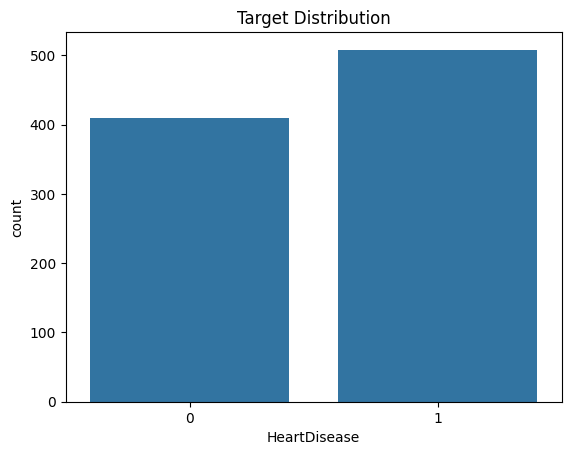

In [ ]:
target_column = "HeartDisease"

# Check class distribution
sns.countplot(x=df[target_column])
plt.title("Target Distribution")
plt.show()

# Handle Missing Values

In [ ]:
# Fill numeric missing values with median
df.fillna(df.median(numeric_only=True), inplace=True)

# Encode Categorical Variables

In [ ]:
label_encoder = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = label_encoder.fit_transform(df[col])

# Split Features and Target
To train on one portion and test on unseen data.

In [ ]:
X = df.drop(target_column, axis=1)
y = df[target_column]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature Scaling

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# MODEL 1 – Logistic Regression
Trained model

Predicted values

Printed accuracy & classification report

In [ ]:
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.8532608695652174

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.87      0.83        77
           1       0.90      0.84      0.87       107

    accuracy                           0.85       184
   macro avg       0.85      0.86      0.85       184
weighted avg       0.86      0.85      0.85       184



# MODEL 2 – Random Forest
Trained RF model

Predicted values

Printed accuracy & classification report

In [ ]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.875

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.86      0.85        77
           1       0.90      0.89      0.89       107

    accuracy                           0.88       184
   macro avg       0.87      0.87      0.87       184
weighted avg       0.88      0.88      0.88       184



# Risk Categorization
Converted probabilities into:

Low Risk

Medium Risk

High Risk

In [ ]:
# Get predicted probabilities
y_prob = rf_model.predict_proba(X_test)[:, 1]

# Convert probabilities to risk categories
risk_category = []
for p in y_prob:
    if p < 0.3:
        risk_category.append("Low Risk")
    elif p < 0.7:
        risk_category.append("Medium Risk")
    else:
        risk_category.append("High Risk")

# Add to dataframe for inspection
df_results = pd.DataFrame(X_test, columns=X.columns)
df_results["Predicted Risk"] = risk_category
df_results["Actual"] = y_test.values
df_results.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up,Predicted Risk,Actual
0,0.999024,0.376415,-0.043312,-0.542709,1.691748,-0.836286,-1.849780,2.068955,-0.532181,-0.213504,0.808179,-0.487621,-0.838461,-1.03325,1.179356,Low Risk,0
1,-0.069591,0.647765,2.943471,-0.542709,-0.244093,-0.836286,0.540605,-0.483336,1.879059,-0.213504,0.808179,-0.487621,-0.838461,0.96782,-0.847921,High Risk,1
2,1.212747,1.461816,-1.846478,1.842609,-0.560148,0.272552,0.540605,-0.483336,-0.532181,-0.213504,-1.237350,2.050774,-0.838461,0.96782,-0.847921,High Risk,1
3,0.250993,-0.166285,-1.846478,-0.542709,-0.560148,0.087745,0.540605,-0.483336,-0.532181,-0.213504,-1.237350,-0.487621,1.192662,0.96782,-0.847921,High Risk,1
4,0.037270,-1.360226,1.010846,-0.542709,0.783088,-0.836286,0.540605,2.068955,-0.532181,-0.213504,0.808179,-0.487621,-0.838461,-1.03325,1.179356,Low Risk,0


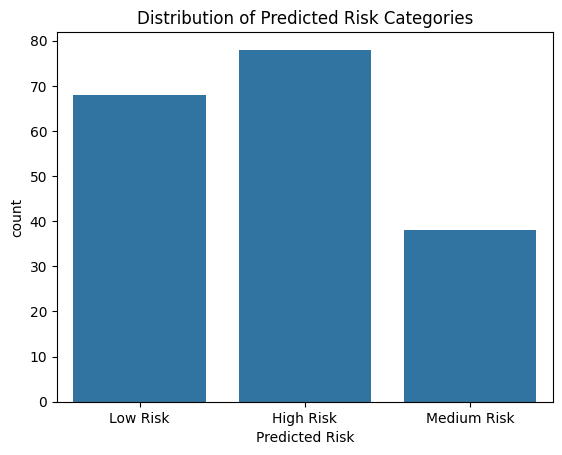

In [ ]:
sns.countplot(x="Predicted Risk", data=df_results)
plt.title("Distribution of Predicted Risk Categories")
plt.show()

# Error Analysis
Analyzed:

False Positives

False Negatives

In [ ]:
# Get False Negatives and False Positives
false_negatives = df_results[(df_results["Actual"]==1) & (df_results["Predicted Risk"]=="Low Risk")]
false_positives = df_results[(df_results["Actual"]==0) & (df_results["Predicted Risk"]=="High Risk")]

print("False Negatives (sick predicted healthy):", len(false_negatives))
print("False Positives (healthy predicted sick):", len(false_positives))

# Optional: Inspect some rows
false_negatives.head()
false_positives.head()

False Negatives (sick predicted healthy): 8
False Positives (healthy predicted sick): 2


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up,Predicted Risk,Actual
21,-0.603898,0.919115,0.252592,-0.542709,-0.244093,0.087745,-1.84978,-0.483336,-0.532181,-0.213504,0.808179,-0.487621,1.192662,0.96782,-0.847921,High Risk,0
173,-0.176452,-0.166285,-0.182017,-0.542709,0.150977,0.549761,-1.84978,-0.483336,-0.532181,-0.213504,0.808179,-0.487621,1.192662,0.96782,-0.847921,High Risk,0


# ROC Curve
Shows trade-off between recall & false positive rate

• Accuracy, Precision, Recall, F1-score

Measures performance quality

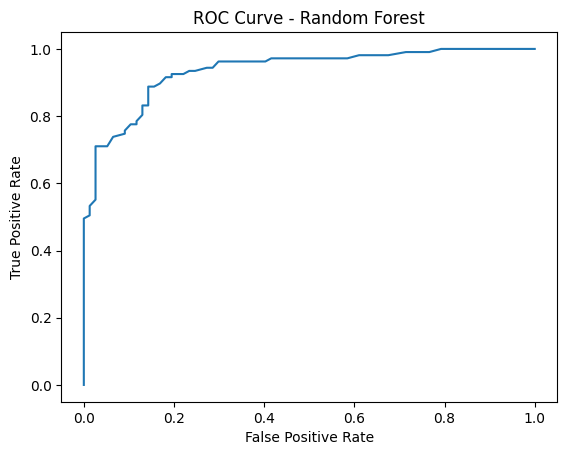

ROC AUC Score: 0.9351863090180847


In [ ]:
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob_rf)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.show()

print("ROC AUC Score:", roc_auc_score(y_test, y_prob_rf))

# Feature Importance
To understand which features influence prediction most (model explainability).



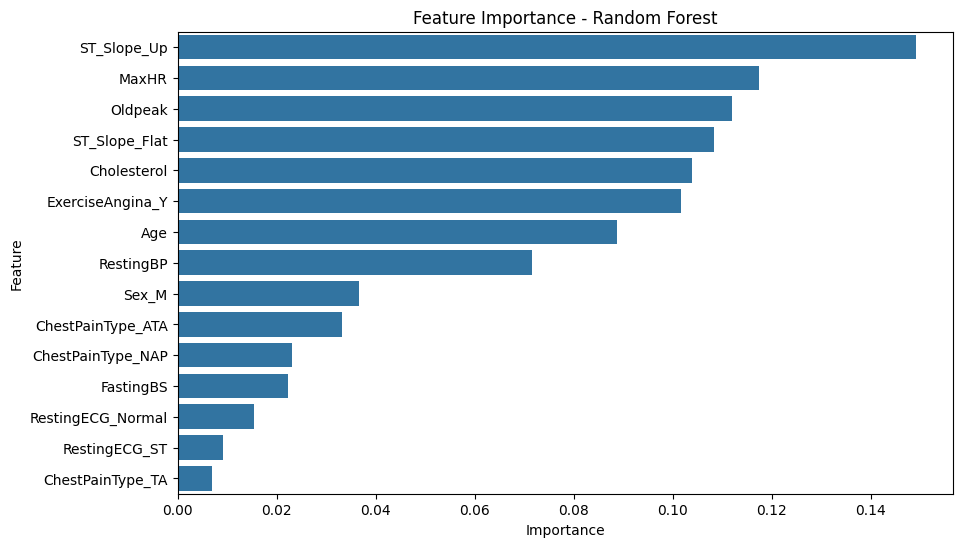

In [ ]:
importances = rf_model.feature_importances_
feature_names = X.columns

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=feature_importance_df)
plt.title("Feature Importance - Random Forest")
plt.show()

# Confusion Matrix

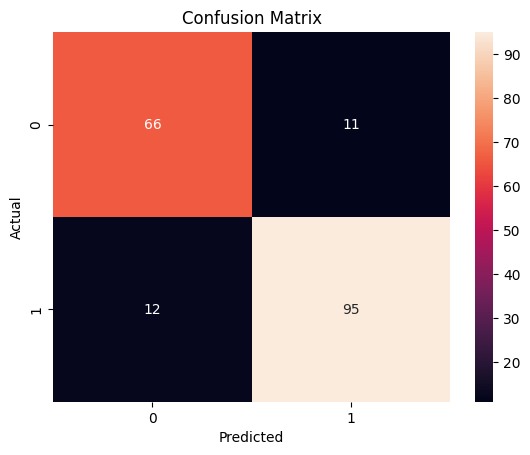

In [ ]:
cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Conclusion

In this project, we developed a machine learning model to predict the risk of heart attack using patient health data. Two models were implemented and compared: Logistic Regression and Random Forest.

After evaluation, the Random Forest model performed better, achieving an accuracy of 87.5%, along with strong precision, recall, and F1-score values. The ROC curve analysis further confirmed that the model has good discriminative ability in distinguishing between high-risk and low-risk patients.

Feature importance analysis revealed that variables such as age, cholesterol levels, maximum heart rate, and chest pain type play a significant role in predicting heart attack risk. This provides interpretability and makes the model more medically meaningful.

Additionally, risk categorization (Low, Medium, High) was implemented using predicted probabilities, making the model more practical for real-world healthcare scenarios. Error analysis highlighted the importance of minimizing false negatives, as misclassifying high-risk patients as low-risk could have serious medical consequences.

# Future Work

Although the model performs well, there are several areas for improvement:

Using a larger and more diverse dataset

Incorporating additional clinical features such as ECG data

Performing hyperparameter tuning to further optimize performance

Developing a simple web-based interface for real-time prediction

Overall, this project demonstrates how machine learning can assist in early heart attack risk detection and support medical decision-making. While not a replacement for professional diagnosis, such models can serve as supportive tools in preventive healthcare systems.